# Dataset Preparation

- Create atoms objects for guess structures
- output: pd.series of ase objects pr pymatgen objects
- calculate garget property for learning set: formation energies


In [1]:
from Tools.DatasetTools.Commoms import *
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
from Tools.DatasetTools.Tools import need_to_update
from Tools.DatasetTools.SublatticeSorter import *
from pymatgen.io.ase import AseAtomsAdaptor
from mendeleev import element
import matplotlib.legend

In [2]:
import matplotlib

In [3]:
from matplotlib import colormaps

In [4]:

from scipy.interpolate import interp1d

In [5]:
from matplotlib.lines import Line2D
plt.rc('font', size=18)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)
plt.rc('axes', labelsize=22)
plt.rc('figure', figsize=(10,8))

In [6]:
#from mp_api.client import MPRester

# options 

In [7]:
dataset = 'Fe-Mo'  # 'Cr-Co-W' 'Fe-Mo'
cases = ['POSCAR.initial', 'POSCAR.relaxed-all']
rescale_by_atoms = True #  False]
subcases = ['rescaled',  'noscaled' ] 
Force = True
CuratedBS = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')

In [8]:
MP_keys = {'Fe' : 'mp-13', 'Mo' : 'mp-129'}

In [9]:
BS = pd.read_pickle(CuratedBS)

In [10]:
bcc_bs = BS.loc[BS.index.str.contains('Fe.*bcc.*FM', regex=True)]

In [11]:
bcc_bs

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase
Fe_pv1.bcc.FM,bulk bcc.FM,11.352006 A,-8.254946,170.727430 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.016,0,1,...,11.368846,Fe_pv,,1,0,1,1.0,0.0,FM,bcc
Fe_pv2.bcc-cubic.FM,bulk bcc-cubic.FM,11.367016 A,-8.254808,187.308419 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.015,0,1,...,11.368059,Fe_pv,,2,0,2,1.0,0.0,FM,bcc


In [12]:
Features = Featurizer(BS)

In [13]:
BS.dropna().describe()

,nelem,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
count,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000
mean,1.844068,12.830508,10.210169,23.040678,0.506328,0.493672
std,0.363408,10.605724,9.526363,13.627892,0.294277,0.294277
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,2.000000,4.500000,2.000000,13.000000,0.266667,0.264151
50%,2.000000,10.000000,8.000000,24.000000,0.500000,0.500000
75%,2.000000,18.000000,16.000000,30.000000,0.735849,0.733333
max,2.000000,53.000000,52.000000,53.000000,1.000000,1.000000


## Prepare targets 

One target still missing is formation Energy. Some Convenience functions to do this has been set

In [14]:
if 'Fe' in dataset:
    ground_states= Features.get_ground_states_energies(force_mag_phase=('Fe_pv', 'NM', 'fcc'))
else:
    ground_states = Features.get_ground_states_energies()

In [15]:
ground_states

{('Fe_pv1', 'bcc', 'FM'): -8.254946325451682,
 ('Fe_pv2', 'hcp', 'NM'): -8.184069259094203,
 ('Fe_pv4', 'fcc', 'NM'): -8.104999634269971,
 ('Mo_sv1', 'bcc', 'FM'): -10.93279164773494,
 ('Mo_sv1', 'bcc', 'NM'): -10.932826414200642}

As seen, at this point ground states are badly determined. They will be calculated after sanitation of dft data

In [16]:
this_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv1', 'bcc', 'FM')]
    this_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv2', 'hcp', 'NM')]
if 'Mo' in dataset:                                                     
    this_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv1', 'bcc', 'FM')]
    this_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv1', 'bcc', 'NM')]

correcting for Fe


In [17]:
this_other_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_other_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv1', 'bcc', 'FM')]
    this_other_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv4', 'fcc', 'NM')]
if 'Mo' in dataset:                                                            
    this_other_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv1', 'bcc', 'FM')]
    this_other_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv1', 'bcc', 'NM')]

correcting for Fe


In [18]:
BS['EF_fmbcc'] = Features.get_formation_energies(this_ground_states, force_reference_energy={'Fe_pv': ground_states[('Fe_pv1', 'bcc', 'FM')]})

In [19]:
BS['EF_nmhcp'] =  Features.get_formation_energies(this_ground_states)

In [20]:
BS['EF_nmfcc'] =  Features.get_formation_energies(this_other_ground_states)

In [21]:
BS.describe()

,nelem,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
count,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000
mean,1.844068,12.830508,10.210169,23.040678,0.506328,0.493672,0.248244,0.227135,0.203585
std,0.363408,10.605724,9.526363,13.627892,0.294277,0.294277,0.161945,0.161887,0.165803
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,-0.015627,-0.042837,-0.085492
25%,2.000000,4.500000,2.000000,13.000000,0.266667,0.264151,0.119131,0.100613,0.073087
50%,2.000000,10.000000,8.000000,24.000000,0.500000,0.500000,0.222698,0.189678,0.167821
75%,2.000000,18.000000,16.000000,30.000000,0.735849,0.733333,0.360658,0.335562,0.308816
max,2.000000,53.000000,52.000000,53.000000,1.000000,1.000000,0.720442,0.720423,0.720423


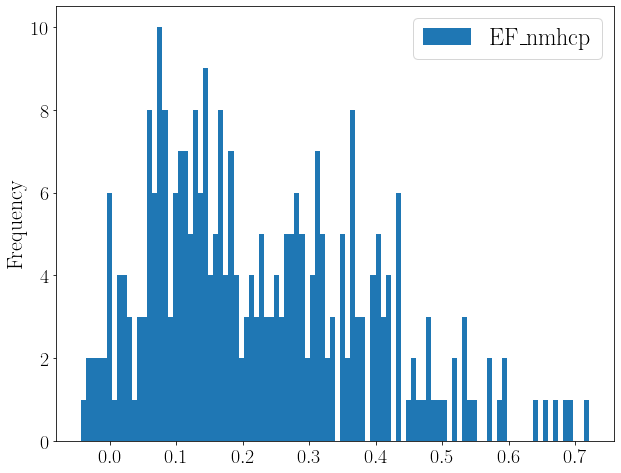

In [22]:
fig, ax =  plt.subplots()
for target_case in ['EF_nmhcp']:
    ax = BS[target_case].plot.hist(ax=ax, label = target_case, bins=100)
ax.legend()

chech that the chemistry resetting is correct!

In [23]:
ground_states

{('Fe_pv1', 'bcc', 'FM'): -8.254946325451682,
 ('Fe_pv2', 'hcp', 'NM'): -8.184069259094203,
 ('Fe_pv4', 'fcc', 'NM'): -8.104999634269971,
 ('Mo_sv1', 'bcc', 'FM'): -10.93279164773494,
 ('Mo_sv1', 'bcc', 'NM'): -10.932826414200642}

In [24]:
ground_state_samples = pd.Series(ground_states).index.map(lambda t: '.'.join(t))

In [25]:
ground_state_samples

Index(['Fe_pv1.bcc.FM', 'Fe_pv2.hcp.NM', 'Fe_pv4.fcc.NM', 'Mo_sv1.bcc.FM',
       'Mo_sv1.bcc.NM'],
      dtype='object')

In [26]:
BS.query('index.str.contains("fcc|bcc|hcp") and nelem==1')[['V0', 'E0', 'B0',target_case]]

,V0,E0,B0,EF_nmhcp
Fe_pv1.bcc.FM,11.368846,-8.254946,189.406244,0.000000
Fe_pv1.bcc.NM,10.479995,-7.790655,268.877068,0.393414
Fe_pv2.hcp.FM,12.027985,-8.06563,165.560281,0.189316
Fe_pv2.hcp.NM,10.193111,-8.184069,287.452557,0.000000
Fe_pv4.fcc-cubic.NM,10.248683,-8.105,283.806776,0.079070
Mo_sv2.hcp.NM,16.137691,-10.497905,237.378947,0.434922
Mo_sv4.fcc-cubic.FM,16.053153,-10.513984,238.623024,0.418808
Mo_sv4.fcc-cubic.NM,16.060272,-10.513042,241.0949,0.419785
Fe_pv1.fcc.FM,12.02106,-8.107124,167.359696,0.147823
Mo_sv1.bcc.FM,15.827845,-10.932792,257.480611,0.000000


Remove FM R from training:

In [27]:
BS = BS[~(( BS.Phase == "R" ) & (BS.Mag == 'FM'))]

In [28]:
BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478647,0.478647,0.478647
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.153982,0.133922,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403259,0.403259,0.403259
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077194,0.058294,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.14633,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374515,0.363611,0.351446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111077,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.000000,0.000000,FM,C15,0.143869,0.143869,0.143869
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932826,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837504,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095323,0.095323,0.095323
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511039,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421788,0.421788,0.421788


In [29]:
BS.to_pickle("Fe-Mo/FurtherCuratedParsedBriefSummary.pkl")

# guess structures: Define atomic volumes 

In [30]:
#atom_volume_keys = {}
#with  MPRester("XMK2lneoOyVOQDnhEnVmyX3h4dyJuSyo") as mpr:
#    for atom, key in MP_keys.items():
#        result =mpr.summary.search(material_ids=[key])[0]
#        total_vol = result.volume
#        nsites = result.nsites
#        atom_volume_keys[atom] = total_vol/nsites
# MP Api is not compatible any more

In [31]:
atom_volume_keys = {'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [32]:
Features = Featurizer(BS)

# Sort Poscar files

In [33]:
cases

['POSCAR.initial', 'POSCAR.relaxed-all']

In [34]:
for searchs, subcase in zip(cases, subcases):
#    searchs = 'POSCAR.initial'
    files = get_file_paths(dataset, searchs, csvfile=f'ListOfFiles_{searchs}.csv')

    atomsobjectslocation = os.path.join(dataset,'Atomsobjects')
    sublatticesortersfile = os.path.join(atomsobjectslocation, f'SORTERS_{searchs}.pkl')
    sublatticetagfile = os.path.join(atomsobjectslocation, f'SUBLATICETAGS_{searchs}.pkl')

    if  not os.path.exists(sublatticesortersfile): # need_to_update(sublatticesortersfile) or need_to_update(sublatticetagfile):
        SORTERS, SUBLATICETAGS = get_all_sorters_and_tags(dataset, files)
        SORTERS.to_pickle(sublatticesortersfile)
        SUBLATICETAGS.to_pickle(sublatticetagfile)
    else:
        SORTERS = pd.read_pickle(sublatticesortersfile)
        SUBLATICETAGS = pd.read_pickle(sublatticetagfile)

# Now I have to pick the atoms objects

In [35]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
#database = f'{dataset}/**/{case}'

In [36]:
Atoms_Objects = {}

In [37]:
subcases

['rescaled', 'noscaled']

In [38]:
for searchs, subcase in zip(cases, subcases):
    AtomsFile = os.path.join(atomsobjectslocation,f'{dataset}-{searchs}-{subcase}-AtomsObjects.pkl')
    if subcase == 'rescaled':
        booleanflag = True
    else:
        booleanflag = False
    if False: #not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
        Atoms_Objects[searchs] = pd.read_pickle(AtomsFile)
    else:
        Atoms_Objects[searchs], CantMake_Atoms_Object = Features.get_atoms_object(
            database=dataset,
            rescale_by_atoms=booleanflag,
            reset_chemistry=True,
            file_filter = searchs, #'initial$',
            element_volumes=atom_volume_keys
        )
        Atoms_Objects[searchs].to_pickle(AtomsFile)
        Atoms_Objects[searchs].dropna(inplace=True)
    pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
    Pymatgen_Structures = Atoms_Objects[searchs].copy()
    if not need_to_update(pymatgenfile):
        Pymatgen_Structures = pd.read_pickle(pymatgenfile)
    else:
        Pymatgen_Structures = Atoms_Objects[searchs]['atoms'].apply(AseAtomsAdaptor.get_structure)
        Pymatgen_Structures['file'] = Atoms_Objects[searchs]['file']
        Pymatgen_Structures.to_pickle(pymatgenfile)

    accomodatewrap = Atoms_Objects[searchs].atoms.map(lambda a: a.wrap(pretty_translation=True))
    allindex = Atoms_Objects[searchs].index.intersection(BS.index)
    Atoms_Objects[searchs] = Atoms_Objects[searchs].loc[allindex]
    Atoms_Objects[searchs].to_pickle(AtomsFile)

100%|██████████| 295/295 [00:11<00:00, 26.10it/s]


In [39]:
for case, AtomsObject in Atoms_Objects.items():
    difference = BS.index.difference(AtomsObject.index)
    print(case, difference)

POSCAR.initial Index([], dtype='object')
POSCAR.relaxed-all Index([], dtype='object')


#  visualization of some structures

In [40]:
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [41]:
from ase.visualize.plot import plot_atoms

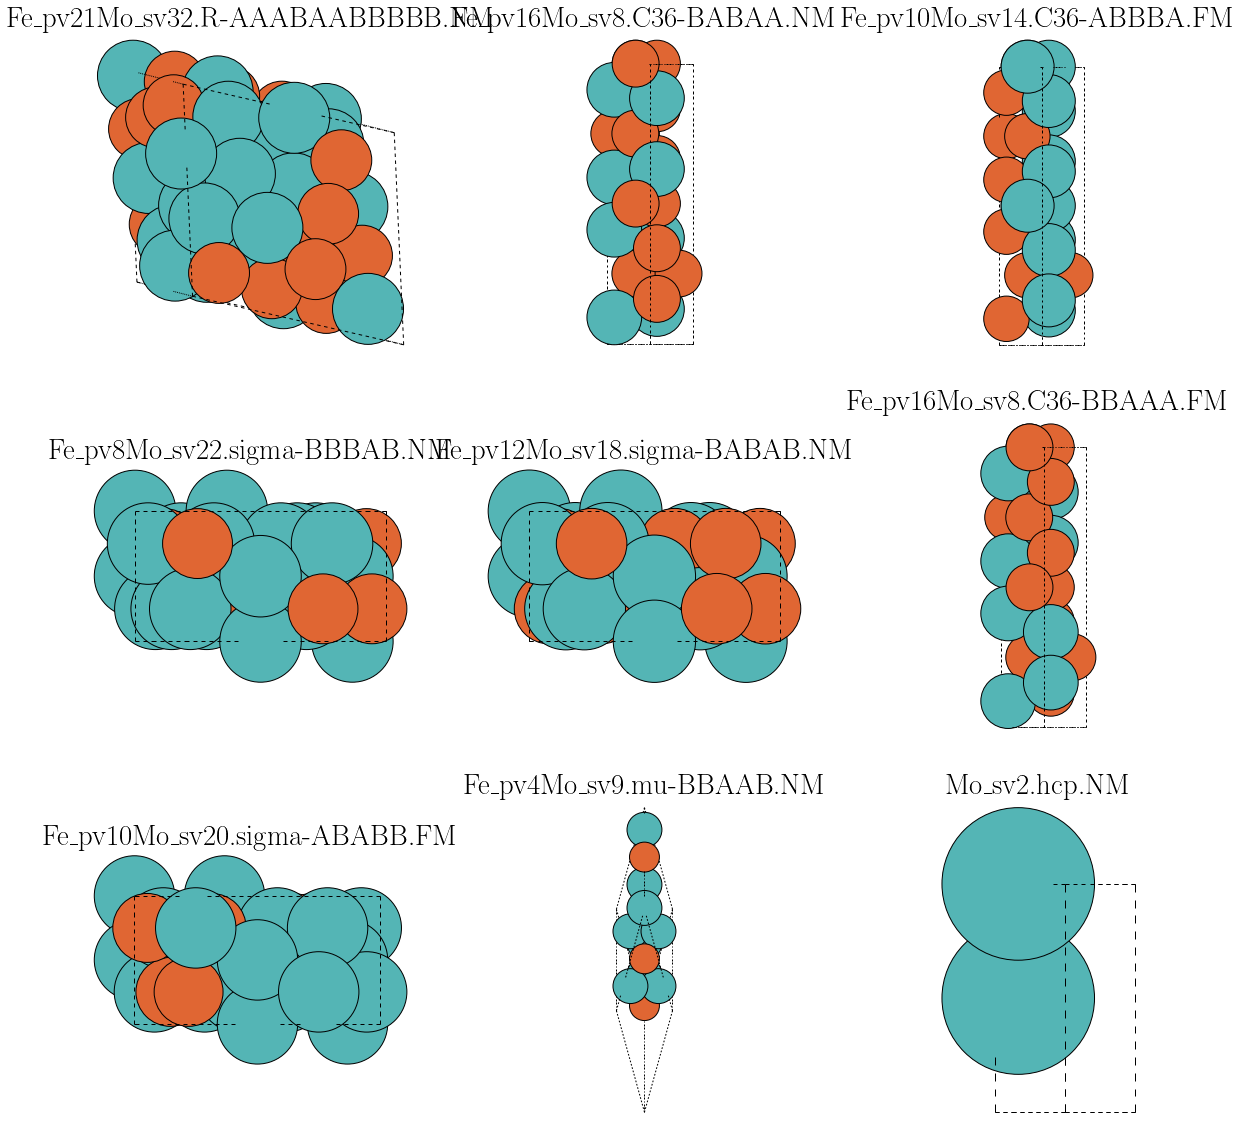

In [42]:
atoms_samples = Atoms_Objects['POSCAR.initial'].atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.items()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [43]:
somesigmas = Atoms_Objects['POSCAR.initial'].atoms[Atoms_Objects['POSCAR.initial'].index.str.contains('sigma')].sample(n=9)

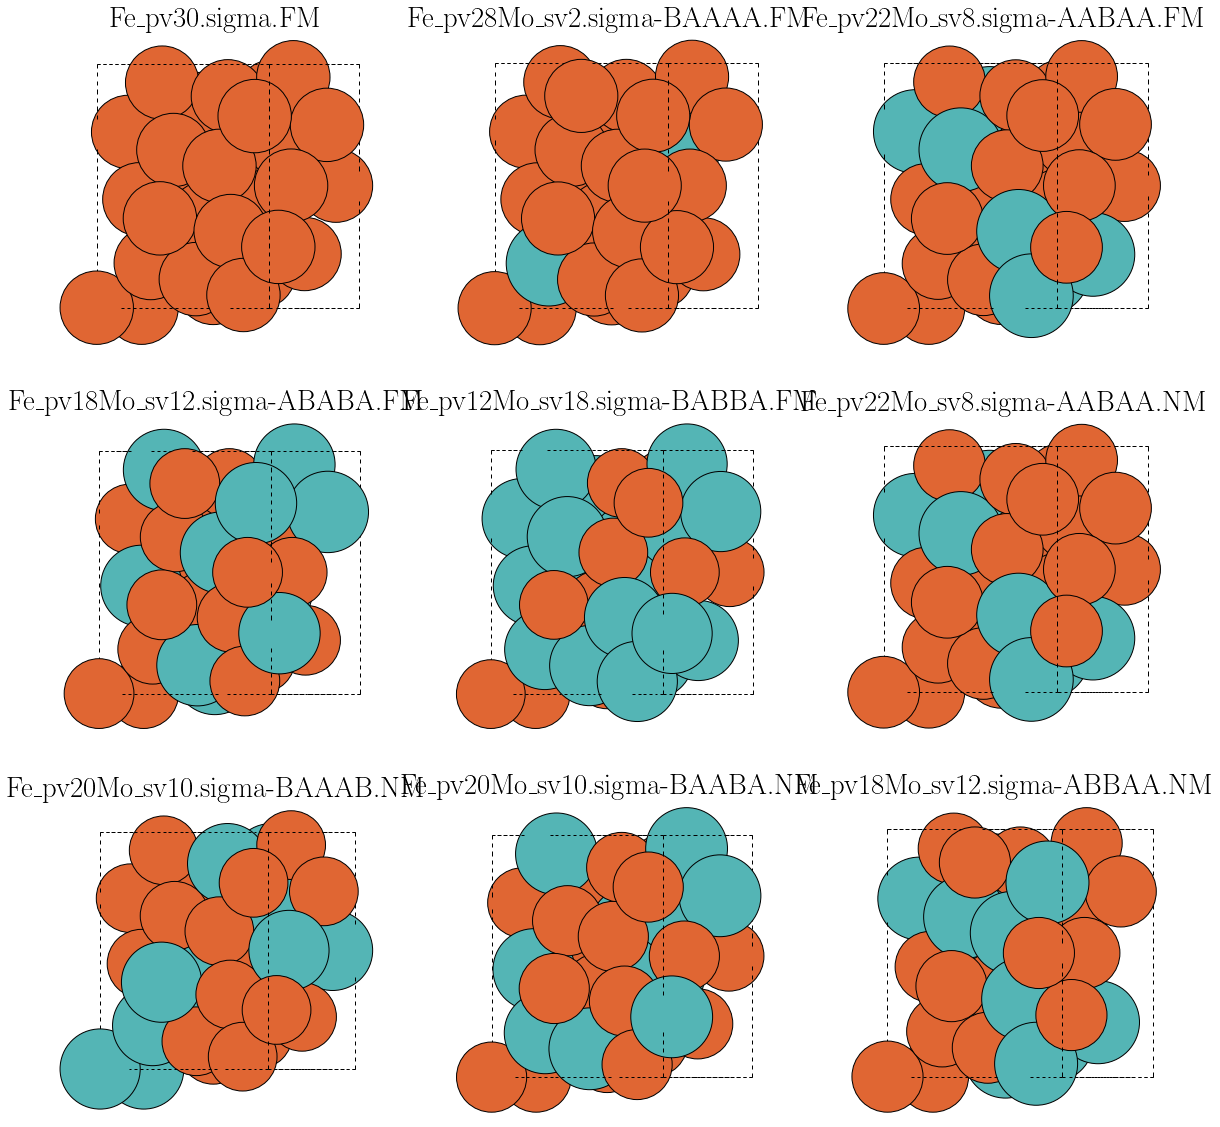

In [44]:
atoms_samples = Atoms_Objects['POSCAR.initial'].atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.items()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.

# Curate Dataset to available structures 

There are still some R structures not available in data but present in briefsummaries

In [45]:
Problems = BS.index.difference(Atoms_Objects['POSCAR.initial'].index)

In [46]:
BS.loc[Problems]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc


In [47]:
BS.dropna().describe()

,nelem,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
count,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000
mean,1.844068,12.830508,10.210169,23.040678,0.506328,0.493672,0.248244,0.227135,0.203585
std,0.363408,10.605724,9.526363,13.627892,0.294277,0.294277,0.161945,0.161887,0.165803
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,-0.015627,-0.042837,-0.085492
25%,2.000000,4.500000,2.000000,13.000000,0.266667,0.264151,0.119131,0.100613,0.073087
50%,2.000000,10.000000,8.000000,24.000000,0.500000,0.500000,0.222698,0.189678,0.167821
75%,2.000000,18.000000,16.000000,30.000000,0.735849,0.733333,0.360658,0.335562,0.308816
max,2.000000,53.000000,52.000000,53.000000,1.000000,1.000000,0.720442,0.720423,0.720423


In [48]:
GoodBS = BS.loc[Atoms_Objects['POSCAR.initial'].index]

In [49]:
GoodBS#.dropna()

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478647,0.478647,0.478647
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.153982,0.133922,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403259,0.403259,0.403259
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077194,0.058294,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.14633,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374515,0.363611,0.351446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111077,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.000000,0.000000,FM,C15,0.143869,0.143869,0.143869
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932826,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837504,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095323,0.095323,0.095323
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511039,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421788,0.421788,0.421788


 # Values as examples in the paper
 

In [50]:
GoodBS.query('Phase.str.contains("sigma") & index.str.contains("AAAAB.NM")')[['Mo_sv','EF_nmhcp']]

,Mo_sv,EF_nmhcp
Fe_pv22Mo_sv8.sigma-AAAAB.NM,0.266667,0.206056


In [51]:
GoodBS.query('Phase.str.contains("sigma") & index.str.contains("AAABA.NM")')[['Mo_sv','EF_nmhcp']]

,Mo_sv,EF_nmhcp
Fe_pv22Mo_sv8.sigma-AAABA.NM,0.266667,0.249122


In [52]:
GoodBS.query('Phase.str.contains("sigma") & index.str.contains("AABAA.NM")')[['Mo_sv','EF_nmhcp']]

,Mo_sv,EF_nmhcp
Fe_pv22Mo_sv8.sigma-AABAA.NM,0.266667,0.099696


In [53]:
GoodBS.query('Phase.str.contains("sigma") & index.str.contains("ABAAA.NM")')[['Mo_sv','EF_nmhcp']]

,Mo_sv,EF_nmhcp
Fe_pv26Mo_sv4.sigma-ABAAA.NM,0.133333,0.127232


In [54]:
GoodBS.query('Phase.str.contains("sigma") & index.str.contains("BAAAA.NM")')[['Mo_sv','EF_nmhcp']]

,Mo_sv,EF_nmhcp
Fe_pv28Mo_sv2.sigma-BAAAA.NM,0.066667,0.22348


In [55]:
FullyCuratedBSFile = os.path.join(dataset,'FullyCuratedParsedBriefSummary.pkl')

In [56]:
GoodBS.to_pickle(FullyCuratedBSFile)

#  Final Distributions of targets

In [57]:
plt.rc('axes.spines', bottom=True, top=True, right=True, left=True)

<AxesSubplot:xlabel='B0', ylabel='Count'>

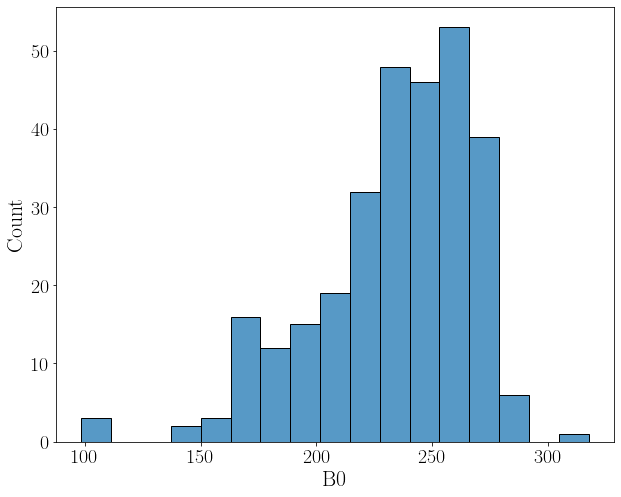

In [58]:
sns.histplot(BS['B0'])

ValueError: s must be a scalar, or float array-like with the same size as x and y

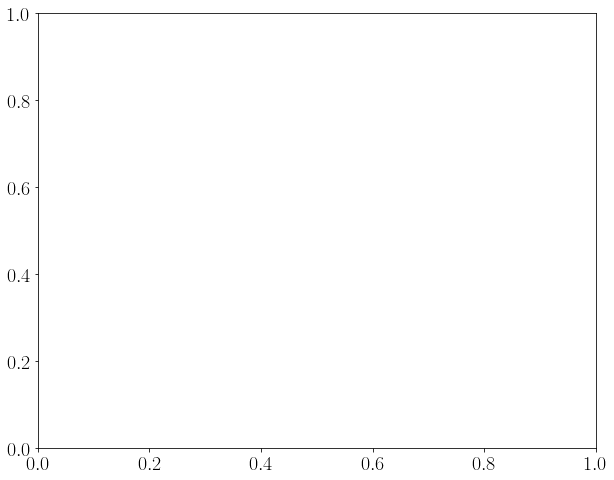

In [59]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(r'$E_0$ (eV)')
plt.xlabel(r'$V_0 (\AA^3)$')
cbar.set_label(r'$B_0$')
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )

# Atomic volumes vs dft

In [ ]:
BS.query('num_atoms == 1').groupby('E0').min('E0')#['V0']#reset_index()

,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
E0,,,,,,,,,,,
-10.932821,1,258.072533,15.828552,1,0,1,0.0,1.0,0.000000,0.000000,0.000000
-10.932755,1,251.877901,15.825081,1,0,1,0.0,1.0,0.000000,0.000000,0.000000
-10.511038,1,239.434813,16.058793,1,0,1,0.0,1.0,0.421784,0.421784,0.421784
-8.255228,1,210.632901,11.356868,1,0,1,1.0,0.0,0.000000,0.000000,0.000000
-8.107128,1,167.384487,12.021393,1,0,1,1.0,0.0,0.148100,0.148100,0.148100
-7.790659,1,269.455898,10.481600,1,0,1,1.0,0.0,0.464569,0.393413,0.314353


In [61]:
Fe_unary = BS.query('num_atoms == 1 and Fe_pv == 1')

In [62]:
V_GS_Fe = Fe_unary[Fe_unary.E0 == Fe_unary.E0.min()].V0

In [63]:
V_GS_Fe

Fe_pv1.bcc.FM    11.368846
Name: V0, dtype: object

In [64]:
Mo_unary = BS.query('num_atoms == 1 and Mo_sv == 1')

In [65]:
V_GS_Mo = Mo_unary[Mo_unary.E0 == Mo_unary.E0.min()].V0

In [66]:
V_GS_Mo

Mo_sv1.bcc.NM    15.828877
Name: V0, dtype: object

In [67]:
norm = plt.Normalize(BS['Fe_pv'].min(), BS['Fe_pv'].max())
sm = plt.cm.ScalarMappable(norm=norm, cmap='rainbow')
sm.set_array([])

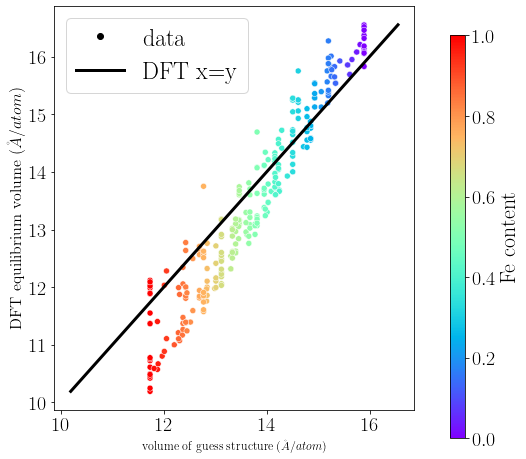

In [68]:
fig = plt.figure()
axs = fig.add_axes([0.25, 0.2, 0.5, 0.7])
#axs = fig.add_axes([ 0.15, 0.2, 0.6, 0.7 ])# plt.subplots() #1, len(Atoms_Objects), figsize = (10,5), sharey=True)
#for (case, atoms_df), ax in zip(Atoms_Objects.items(), axs):
volumes = Atoms_Objects['POSCAR.initial']['atoms'].map(lambda a: a.get_volume()/a.get_global_number_of_atoms())
sns.scatterplot(x=volumes.values, y=BS['V0'].values, hue=BS['Fe_pv'], ax=axs, palette = 'rainbow', legend='brief', markers=BS.Phase)
#sns.lineplot(x=BS['V0'].values, y=BS['V0'].values,ax = axs, color='k', label='x=y', legend='brief')#, hue=BS['Fe_pv'], palette='rainbow')
axs.plot([BS['V0'].min(), BS['V0'].max()],[BS['V0'].min(), BS['V0'].max()], 'k' )
axs.set_ylabel(r'DFT equilibrium volume ($ \AA /atom $)', fontsize='16')
axs.set_xlabel(r'volume of guess structure ($\AA / atom$)', fontsize='12')
axs.legend().remove()
#ax.legend(['data', 'x=y'])
handles = [
    plt.Line2D([0],[0], marker='o', linestyle='', c='k'),
    plt.Line2D([0],[0],linestyle='-', c='k')
]
labels=[
    'data',
    'DFT x=y'
]
axs.legend(handles, labels)
cbarax = fig.add_axes([0.8, 0.15, 0.02, 0.7])
cbar = axs.figure.colorbar(sm, cax=cbarax)
cbar.set_label('Fe content', fontsize=22)
fig.tight_layout()
plt.savefig(f'{dataset}/graphs/{dataset}-dftV_vs_gressV.pdf')

In [69]:
colors = sns.color_palette('bright')
training_BS = BS.query('Phase != "bcc" & Phase != "hcp" & Phase != "fcc" & Phase != "R"')
colors

[(0.00784313725490196, 0.24313725490196078, 1.0),
 (1.0, 0.48627450980392156, 0.0),
 (0.10196078431372549, 0.788235294117647, 0.2196078431372549),
 (0.9098039215686274, 0.0, 0.043137254901960784),
 (0.5450980392156862, 0.16862745098039217, 0.8862745098039215),
 (0.6235294117647059, 0.2823529411764706, 0.0),
 (0.9450980392156862, 0.2980392156862745, 0.7568627450980392),
 (0.6392156862745098, 0.6392156862745098, 0.6392156862745098),
 (1.0, 0.7686274509803922, 0.0),
 (0.0, 0.8431372549019608, 1.0)]

In [70]:
phase_label = {
    'sigma': r"$\sigma$",
    'chi': r"$\chi$",
    'mu': r"$\mu$",
    'C36': 'C36',
    'C14': 'C14',
    'C15': 'C15',
    'A15': 'A15',
    'R': 'R',
    'lambda': r"$\lambda$ (C14)"
}

[Text(0, 0, 'C36'), Text(0, 1, 'mu'), Text(0, 2, 'sigma'), Text(0, 3, 'C14'), Text(0, 4, 'chi'), Text(0, 5, 'C15'), Text(0, 6, 'A15')]
['C36', '$\\mu$', '$\\sigma$', 'C14', '$\\chi$', 'C15', 'A15']


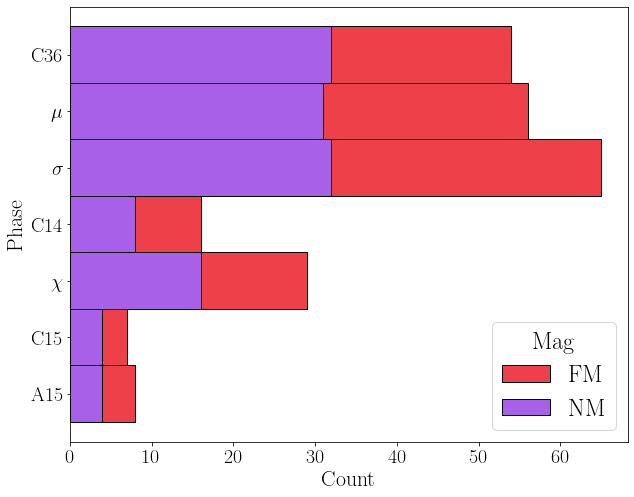

In [71]:
fig, ax = plt.subplots()
sns.histplot(training_BS, y='Phase', hue='Mag', multiple='stack', palette=[colors[3], colors[4]], ax = ax)
ticks = ax.get_yticklabels()
#ax.set_xticklabels(ticklabels)
fig.savefig('Fe-Mo/graphs/Fe-Mo_StackCounts_Sanitized.pdf')
print(ticks)
new_ticks = [phase_label[label._text] for label in ticks if label._text != '']
print(new_ticks)
ax.set_yticklabels(new_ticks)
fig.savefig('Fe-Mo/graphs/Fe-Mo_StackCounts_Sanitized.pdf')


# convex hulls with magnetic mixing

In [72]:
from Tools.DatasetTools.Tools import Plotting

In [73]:
phases = BS.Phase.unique()

In [74]:
CHULL = {}

In [75]:
P = Plotting()

# Mixed convex hull

In [76]:
for phase, bs_phase in BS.groupby(by='Phase'):
    CHULL.update (P.get_convex_hulls({phase: bs_phase}, ['Fe', 'Mo'],getproperty='EF_nmhcp'))
colors = colormaps['tab20'].colors
xy = {}
color_seq = {}
#for (phase, chull), c in zip ( CHULL.items(), colors ):
for phase, chull in CHULL.items(): #, colors ):
    if phase == 'bcc':
        continue
    if phase == 'fcc':
        continue
    if phase == 'hcp':
        continue
#    if phase == 'chi':
#        continue
#    if phase == 'R':
#        continue
    bs_phase = BS[BS.Phase == phase]
    vertices = np.unique( chull.simplices[chull.good])
    xy[phase]= bs_phase.iloc[vertices][['Fe_pv', target_case]].sort_values(by='Fe_pv')
#    l = ax.plot(xy[phase]['Fe_pv'].values, xy[phase][target_case].values, label = phase_label[phase])#, color=c)
#    ax.scatter(bs_phase['Fe_pv'], bs_phase[target_case], s=100, edgecolor='k', linewidth=2)#, facecolor=c)
#    color_seq[phase] = l[0].get_color()
#ax.legend(bbox_to_anchor=(1,1))
#ax.axhline(c='k', ls='--')
#ax.set_xlabel ('$x_{Fe}$')
#ax.set_xlim([0,1])
#ax.set_ylabel('$\Delta E_F$')
from scipy.interpolate import interp1d
interpolation_y = {}
x = np.linspace(0,1,100)
for phase, this_xy in xy.items():
    interpolation = interp1d(this_xy['Fe_pv'], this_xy[target_case])
    interpolation_y[phase]=interpolation(x)
compare_chulls = pd.DataFrame.from_dict(interpolation_y)
phase_range = {}
for phase in compare_chulls:
    mask = compare_chulls[phase].le(compare_chulls.min(axis=1))
    phase_range[phase] = x[mask]
alphas = {
    'lambda': 1,
    'R':0.3,
    'sigma': 0.3,
    'mu': 0.3
}
experimental_range = {
    'sigma': [0.4,0.55],
    'R' : [0.6,0.65],
    'mu' : [0.6, 0.55],
    'lambda': [0.655, 0.66]
}
#color_seq['R'] = 'grey'
pallete_seq = sns.color_palette('tab10', len(CHULL))
color_seq = {phase: color for phase, color in zip(CHULL.keys(), pallete_seq)}
color_seq['lambda'] = '#000000'
CHULL.keys()
marker_seq = {'A15': 'p', 'C14': 'X','C15':'>', 'C36': 'o', 'R': 'h', 'bcc':'.', 'chi': 'D', 'fcc': 9, 'hcp':'<', 'mu': 'D', 'sigma': 's'}
from matplotlib.lines import Line2D
BS.query('Mag == "FM" and Phase == "A15"')


,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv2Mo_sv6.A15-BA.FM,bulk A15-BA.FM,14.757480 A,-10.202326,238.003165 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,6,8,0.25,0.75,FM,A15,0.061004,0.061004,0.061004
Fe_pv6Mo_sv2.A15-AB.FM,bulk A15-AB.FM,12.624795 A,-8.867443,203.806345 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,6,2,8,0.75,0.25,FM,A15,0.056965,0.056965,0.056965
Fe_pv8.A15.FM,bulk A15.FM,11.558019 A,-8.16978,91.497861 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,8,0,8,1.00,0.00,FM,A15,0.085166,0.085166,0.085166
Mo_sv8.A15.FM,bulk A15.FM,16.077050 A,-10.839027,253.594611 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,8,0,8,0.00,1.00,FM,A15,0.093765,0.093765,0.093765


In [77]:
color_seq

{'A15': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'C14': (1.0, 0.4980392156862745, 0.054901960784313725),
 'C15': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'C36': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'R': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'bcc': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 'chi': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 'fcc': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 'hcp': (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 'mu': (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
 'sigma': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'lambda': '#000000'}

In [78]:
texlabels = {
    'A15': '$A$15',
    'C15': '$C$15',
    'chi': '$\chi$',
    'sigma': '$\sigma$',
    'C14':'$C$14',
    'C36': '$C$36',
    'mu': '$\mu$',
    'R': '$R$'
}

In [79]:
def plot_one_chull(phase, chull,  bs_phase, tax):
    vertices = np.unique( chull.simplices[chull.good])
    xy[phase]= bs_phase.iloc[vertices][['Fe_pv', target_case]].sort_values(by='Fe_pv')
    tax.plot(xy[phase]['Fe_pv'].values, xy[phase][target_case].values,  color=color_seq[phase]) #label = phase_label[phase],

def plot_all_chulls(thisCHULLS, thisBS, exept_phases, ax, handles=[], labels=[]):
    for phase, chull in thisCHULLS.items(): #, colors ):
        if phase in exept_phases:
            continue
        bs_phase = thisBS[thisBS.Phase == phase]
        labels.append(texlabels.get(phase))
        handles.append(Line2D([0],[0], color=color_seq[phase], linewidth=5, marker = marker_seq[phase], markersize=15, markeredgecolor='k'))
        plot_one_chull(phase, chull, bs_phase, ax)
    return handles, labels


def plot_all_points(thisBS, exceptions, ax, handles=[], labels=[], markerlinewidth=1):
    for phase, bs_phase in thisBS.groupby('Phase'):
        if phase in exceptions:
            continue
        ax.scatter(bs_phase['Fe_pv'], bs_phase[target_case], s=100, edgecolor='k',marker=marker_seq[phase], linewidth=markerlinewidth, facecolor=color_seq[phase], zorder=10, clip_on=False)
        thetexlabel = texlabels.get(phase)
        if thetexlabel not in labels:
            labels.append(texlabels.get(phase))
            handles.append(Line2D([0],[0], color=color_seq[phase], linewidth=5, marker = marker_seq[phase], markersize=15, markeredgecolor='k'))
    return handles, labels

ax_spec = [0.2, 0.1, 0.7, 0.7]

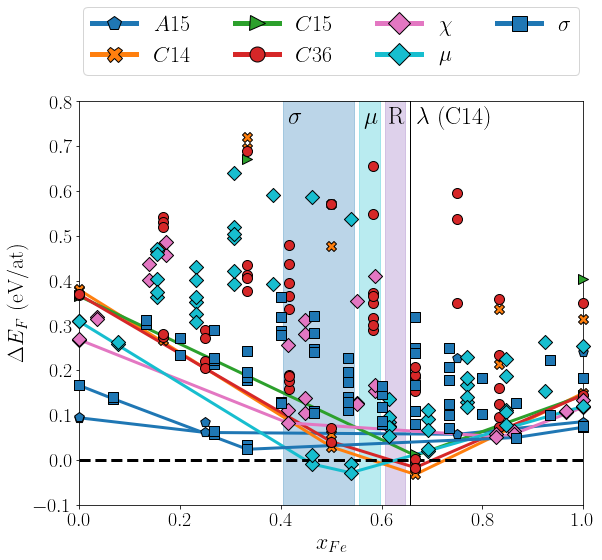

In [80]:
fig = plt.figure()#figsize=(12,8))
ax = fig.add_axes(ax_spec)#[0.2, 0.1, 0.7, 0.7])
exceptphases = [ 'bcc', 'fcc', 'hcp', 'R' ]
#for (phase, chull), c in zip ( CHULL.items(), colors ):
handles, labels = plot_all_chulls(CHULL, BS, exceptphases, ax, handles=[], labels=[] )

handles, labels = plot_all_points(BS, exceptphases, ax, handles, labels)

#    color_seq[phase] = l[0].get_color()
for label, trange in  experimental_range.items():
    xmin = min(trange)
    xmax = max(trange)
    this_x = x[ ( x< xmax ) & ( x>xmin )]
    ax.fill_between(this_x,-0.1, 1, alpha = alphas[label], color = color_seq[label])
    ax.annotate(phase_label[label], (xmin+0.015, 0.75))

ax.legend(handles, labels, bbox_to_anchor=(0.5, 1.15), loc='center', ncol=4, fontsize=22)# labelspacing=2)
ax.axhline(c='k', ls='--')
ax.set_xlabel ('$x_{Fe}$')
ax.set_xlim([0,1])
ax.set_ylim([-0.1, 0.8])
ax.set_ylabel('$\Delta E_F$ (eV/at)')
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_ConvexHulls_ExpRanges.pdf')

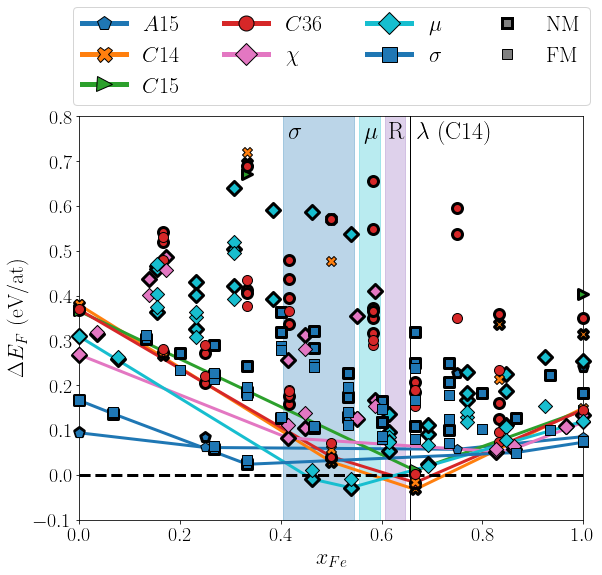

In [81]:
fig = plt.figure()
ax = fig.add_axes(ax_spec)#[0.2, 0.1, 0.6, 0.8])
#for (phase, chull), c in zip ( CHULL.items(), colors ):
exceptions = ['bcc', 'fcc', 'hcp', 'R']
handles = []
labels = []
handles, labels = plot_all_chulls(CHULL, BS, exceptphases, ax, handles=[], labels=[] )


handles, labels = plot_all_points(BS.query('Mag == "NM"'), exceptphases, ax, handles=handles, labels=labels, markerlinewidth=3)

handles, labels = plot_all_points(BS.query('Mag == "FM"'), exceptphases, ax, handles=handles, labels=labels, markerlinewidth=1)


handles.append(Line2D([],[], linestyle='None', marker='s', markersize=10, markerfacecolor='gray', markeredgewidth=3, markeredgecolor='k'))
labels.append('NM')
handles.append(Line2D([],[], linestyle='None', marker='s', markersize=10, markerfacecolor='gray', markeredgewidth=1, markeredgecolor='k'))
labels.append('FM')

#    color_seq[phase] = l[0].get_color()
for label, trange in  experimental_range.items():
    xmin = min(trange)
    xmax = max(trange)
    this_x = x[ ( x< xmax ) & ( x>xmin )]
    ax.fill_between(this_x,-0.1, 1, alpha = alphas[label], color = color_seq[label])
    ax.annotate(phase_label[label], (xmin+0.015, 0.75))
ax.legend(handles, labels, bbox_to_anchor=(0.5, 1.15), loc='center', ncol=4, fontsize=22)#  labelspacing=1.25)
ax.axhline(c='k', ls='--')
ax.set_xlabel ('$x_{Fe}$')
ax.set_xlim([0,1])
ax.set_ylim([-0.1, 0.8])
ax.set_ylabel('$\Delta E_F$ (eV/at)')
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_ConvexHulls_ExpRanges_FMNM.pdf')

# FM convex Hull

In [82]:
FMBS = BS.query('Mag == "FM"').sort_values('Fe_pv')
FMCHULL = {}
for phase, bs_phase in FMBS.groupby(by='Phase'):
    FMCHULL.update (P.get_convex_hulls({phase: bs_phase}, ['Fe', 'Mo'],getproperty='EF_nmhcp', viewpoint=(0.6, -20)))
colors = colormaps['tab20'].colors

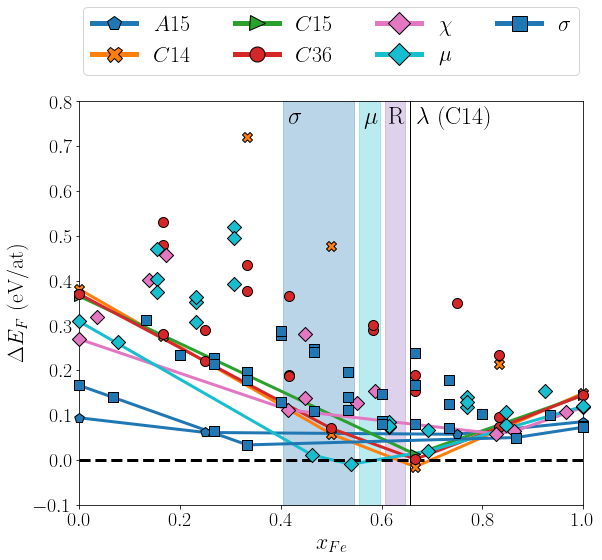

In [83]:
fig = plt.figure()
ax = fig.add_axes(ax_spec)#[0.1, 0.1, 0.7, 0.8])
#for (phase, chull), c in zip ( CHULL.items(), colors ):
exceptions = ['bcc', 'fcc', 'hcp', 'R']
handles = []
labels = []
handles, labels = plot_all_chulls(FMCHULL, FMBS, exceptphases, ax, handles=[], labels=[] )

handles, labels = plot_all_points(FMBS, exceptphases, ax, handles=handles, labels=labels, markerlinewidth=1)

#    color_seq[phase] = l[0].get_color()
for label, trange in  experimental_range.items():
    xmin = min(trange)
    xmax = max(trange)
    this_x = x[ ( x< xmax ) & ( x>xmin )]
    ax.fill_between(this_x,-0.1, 1, alpha = alphas[label], color = color_seq[label])
    ax.annotate(phase_label[label], (xmin+0.015, 0.75))
ax.legend(handles, labels, bbox_to_anchor=(0.5, 1.15), loc='center', ncol=4, fontsize=22)#  labelspacing=1.25)
ax.axhline(c='k', ls='--')
ax.set_xlabel ('$x_{Fe}$')
ax.set_xlim([0,1])
ax.set_ylim([-0.1, 0.8])
ax.set_ylabel('$\Delta E_F$ (eV/at)')
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_FMConvexHulls_ExpRanges_FM.pdf')

# NM convex Hull

In [85]:
NMBS = BS.query('Mag == "NM"').sort_values('Fe_pv')
NMCHULL = {}
for phase, bs_phase in NMBS.groupby(by='Phase'):
    NMCHULL.update (P.get_convex_hulls({phase: bs_phase}, ['Fe', 'Mo'],getproperty='EF_nmhcp', viewpoint=(0.6, -20)))
colors = colormaps['tab20'].colors

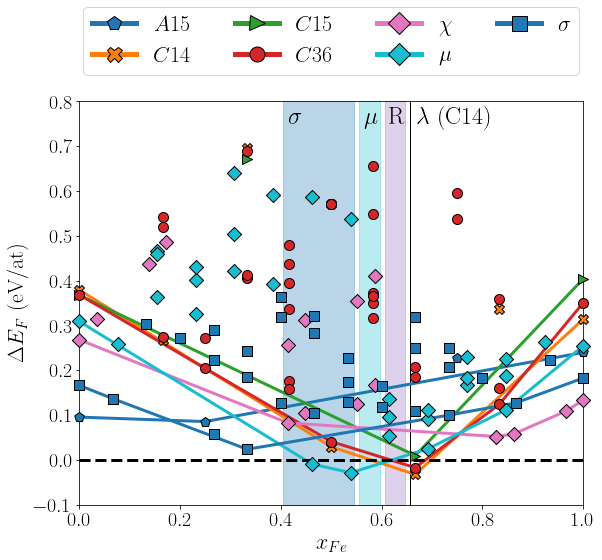

In [86]:
fig = plt.figure()
ax = fig.add_axes(ax_spec)
#for (phase, chull), c in zip ( CHULL.items(), colors ):
exceptphases = ['bcc', 'fcc', 'hcp', 'R']
handles = []
labels = []
handles, labels = plot_all_chulls(NMCHULL, NMBS, exceptphases, ax, handles=[], labels=[] )

handles, labels = plot_all_points(NMBS, exceptphases, ax, handles=handles, labels=labels, markerlinewidth=1)

#    color_seq[phase] = l[0].get_color()
for label, trange in  experimental_range.items():
    xmin = min(trange)
    xmax = max(trange)
    this_x = x[ ( x< xmax ) & ( x>xmin )]
    ax.fill_between(this_x,-0.1, 1, alpha = alphas[label], color = color_seq[label])
    ax.annotate(phase_label[label], (xmin+0.015, 0.75))
ax.legend(handles, labels, bbox_to_anchor=(0.5, 1.15), loc='center', ncol=4, fontsize=22)#  labelspacing=1.25)
ax.axhline(c='k', ls='--')
ax.set_xlabel ('$x_{Fe}$')
ax.set_xlim([0,1])
ax.set_ylim([-0.1, 0.8])
ax.set_ylabel('$\Delta E_F$ (eV/at)')
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_NMConvexHulls_ExpRanges_NM.pdf')

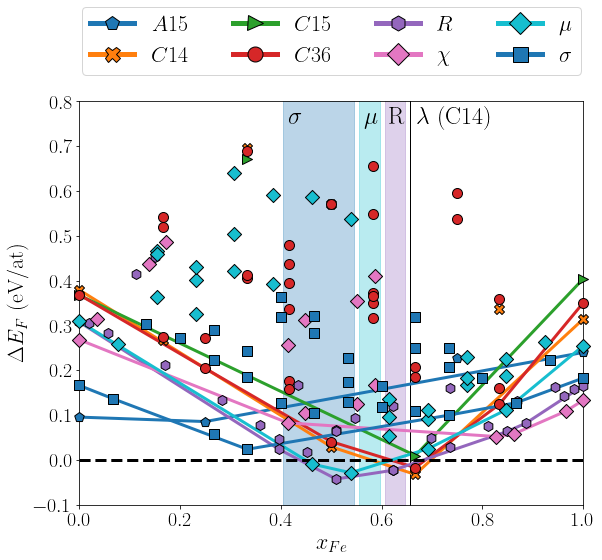

In [145]:
fig = plt.figure()
ax = fig.add_axes(ax_spec)
#for (phase, chull), c in zip ( CHULL.items(), colors ):
exceptphases = ['bcc', 'fcc', 'hcp']#, 'R']
handles = []
labels = []
handles, labels = plot_all_chulls(NMCHULL, NMBS, exceptphases, ax, handles=[], labels=[] )

handles, labels = plot_all_points(NMBS, exceptphases, ax, handles=handles, labels=labels, markerlinewidth=1)

#    color_seq[phase] = l[0].get_color()
for label, trange in  experimental_range.items():
    xmin = min(trange)
    xmax = max(trange)
    this_x = x[ ( x< xmax ) & ( x>xmin )]
    ax.fill_between(this_x,-0.1, 1, alpha = alphas[label], color = color_seq[label])
    ax.annotate(phase_label[label], (xmin+0.015, 0.75))
ax.legend(handles, labels, bbox_to_anchor=(0.5, 1.15), loc='center', ncol=4, fontsize=22)#  labelspacing=1.25)
ax.axhline(c='k', ls='--')
ax.set_xlabel ('$x_{Fe}$')
ax.set_xlim([0,1])
ax.set_ylim([-0.1, 0.8])
ax.set_ylabel('$\Delta E_F$ (eV/at)')
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_NMConvexHulls_ExpRanges_NM_R.pdf')

# samples in convex hull (DFT)

In [87]:
from IPython.display import HTML
import ipywidgets as widgets

In [88]:
nsites = {
    'bcc' : 1,
    'fcc' : 1,
    'hcp' : 2,
    'A15': 2,
    'C15': 2,
    'C14': 3,
    'chi': 4,
    'C36': 5,
    'sigma': 5,
    'sigma_Fe_pv': 5,
    'mu': 5,
    'R': 11
}

In [89]:
def get_config(theindex): #thephaseconfig):
    splitted = theindex.split('.')
    elements = splitted[0]
    thephaseconfig =splitted[1]
    thisnsites = nsites.get(thephaseconfig.split('-')[0])
    if '-' in thephaseconfig:
        return thephaseconfig.split('-')[-1]
    else:
        try:
            if 'Mo' in elements:
                return 'B'*thisnsites
            elif 'Fe' in elements:
                return 'A'*thisnsites
        except Exception as E:
            print(f'problems with {theindex}')

In [90]:
get_config(BS.index[0])

'ABBBB'

In [91]:
get_config(BS.index[-1])

'BB'

In [92]:
BS.index.map(get_config)

Index(['ABBBB', 'AAAABBBBBBB', 'BBABB', 'BBBAB', 'BBBBA', 'BBABB', 'BAB',
       'AAABBBBBBBB', 'BABBB', 'ABBBB',
       ...
       'A2B', 'AB', 'BAABB', 'AAAAA', 'cubic', 'AA', 'B', 'BB', 'B', 'BB'],
      dtype='object', length=291)

In [93]:
BS['config'] = BS.index.map(get_config)

In [94]:
Ws = []
for phase, phasexy in xy.items():
    chull_file = f'{dataset}/results/{dataset}_{phase}_DFT_ConvexHull.tex'
    BS.loc[phasexy.index][['Mo_sv', 'B0', 'V0', 'Mag','config', 'EF_nmhcp',]].to_latex(chull_file, column_format='|'+6*'c|', float_format='%.3f')
    Ws.append(widgets.HTML(BS.loc[phasexy.index][['Fe_pv', 'B0', 'V0', 'Mag','config', 'EF_nmhcp',]].to_html()))

In [95]:
widgets.VBox(Ws)

In [96]:
xy.keys()

dict_keys(['A15', 'C14', 'C15', 'C36', 'R', 'chi', 'mu', 'sigma'])

In [97]:
EF = {}
CHULLBS = pd.DataFrame([])
Ws = []
for phase, phasexy in xy.items():
    thisbs = BS.loc[phasexy.index].sort_values(by='Mo_sv')#[['Mo_sv', 'Fe_pv', 'Phase', 'B0', 'V0', 'Mag','config', 'EF_nmhcp',]]
#    CHULLBS = pd.concat(
#        [
#            CHULLBS, 
#            BS.loc[phasexy.index][['Mo_sv', 'Fe_pv', 'Phase', 'B0', 'V0', 'Mag','config', 'EF_nmhcp',]].sort_values(by='Fe_pv', ascending=False)
#        ],
#        axis = 0
#    )
    for chullinx in thisbs.index:
        EF[chullinx] = {}
        theindexbase = chullinx.split('.')[:-1]
        for mg in ['NM', 'FM']:
            themgindex = '.'.join(theindexbase)+'.'+mg
            if themgindex in BS.index:
                EF[chullinx][mg] = BS.loc[themgindex]['EF_nmhcp']

In [98]:
CHULLBS = pd.DataFrame.from_dict( EF, orient='index' )
CHULLBS = pd.concat([CHULLBS, BS.loc[CHULLBS.index, ['Fe_pv', 'Mo_sv', 'V0', 'B0', 'Phase','config', 'Mag']]], axis = 1)
CHULLBS.index = pd.MultiIndex.from_frame(CHULLBS[['Phase','config', 'Mag']])
CHULLBS.drop(columns=['Mag', 'config', 'Phase'], inplace=True)
CHULLBS.index = CHULLBS.index.droplevel( -1)

In [99]:
full_table_chulls = CHULLBS.loc[['A15', 'C15', 'C14','chi', 'mu', 'C36','sigma','R' ]][['Mo_sv', 'Fe_pv', 'B0', 'V0', 'NM', 'FM']]

In [100]:
full_table_chulls

Mo_sv     Fe_pv          B0         V0        NM  \
Phase config                                                             
A15   AA           0.000000  1.000000  270.810516  10.455612  0.239686   
      BA           0.750000  0.250000  258.110052  14.576366  0.085364   
      BB           1.000000  0.000000  253.867360  16.079894  0.095306   
C15   AA           0.000000  1.000000  254.298994  10.775203  0.404036   
      A2B          0.333333  0.666667  283.004341  12.059935  0.009364   
      BB           1.000000  0.000000  235.693195  16.457592  0.367463   
C14   AAA          0.000000  1.000000  261.891103  10.726385  0.314146   
      BAA          0.333333  0.666667  282.421425  12.031617 -0.032781   
      BBA          0.500000  0.500000  271.659626  13.111142  0.028947   
      BBB          1.000000  0.000000  233.639398  16.550514  0.379248   
chi   AAAA         0.000000  1.000000  277.351790  10.423714  0.133086   
      BAAA         0.034483  0.965517  277.102416  10.574618  0.108602   
      ABAA         0.137931  0.862069  279.962377  11.071831  0.057649   
      BBAA         0.172414  0.827586  277.508550  11.242108  0.051956   
      BBBA         0.586207  0.413793  261.017455  13.604063  0.082416   
      BBBB         1.000000  0.000000  241.387268  16.179402  0.268059   
mu    AAAAA        0.000000  1.000000  268.588590  10.612832  0.254671   
      AAABA        0.153846  0.846154  274.382711  11.266381  0.111182   
      AABBA        0.307692  0.692308  278.292359  11.995227  0.024908   
      AABBB        0.461538  0.538462  275.344022  12.758266 -0.028899   
      BABBB        0.538462  0.461538  270.841242  13.239560 -0.009315   
      BBBBB        1.000000  0.000000  240.033904  16.365202  0.308828   
C36   AAAAA        0.000000  1.000000  259.677233  10.755098  0.350529   
      ABAAA        0.166667  0.833333  274.873021  11.384703  0.123880   
      BBAAA        0.333333  0.666667  281.990379  12.044550 -0.017420   
      BBBAA        0.500000  0.500000  269.196914  13.117004  0.040620   
      BBBBA        0.750000  0.250000  250.226055  14.799694  0.203874   
      BBBBB        1.000000  0.000000  234.479420  16.516438  0.368466   
sigma AAAAA        0.000000  1.000000  276.176253  10.423075  0.182596   
      ABAAA        0.133333  0.866667  273.019722  11.104763  0.127239   
      AABAA        0.266667  0.733333  269.267034  11.858648  0.099695   
      ABBAB        0.666667  0.333333  264.520194  14.000959  0.023512   
      ABBBB        0.933333  0.066667  251.978218  15.689733  0.136478   
      BBBBB        1.000000  0.000000  249.279113  16.111353  0.166128   
R     AAAAAAAAAAA  0.000000  1.000000  274.081057  10.496832  0.165564   
      AAAAAAAAAAB  0.113208  0.886792  277.323503  11.000617  0.082154   
      AAAAAAAAABB  0.150943  0.849057  278.182406  11.168888  0.063301   
      AAAAAAABBBB  0.377358  0.622642  276.595749  12.318164 -0.023359   
      AAAAAABBBBB  0.490566  0.509434  274.512222  12.915438 -0.042841   
      AAABAABBBBB  0.603774  0.396226  265.950317  13.662148  0.023408   
      BBBBBBBBBBB  1.000000  0.000000  238.808096  16.315439  0.307507   

                         FM  
Phase config                 
A15   AA                NaN  
      BA           0.061044  
      BB           0.093726  
C15   AA           0.144169  
      A2B          0.012455  
      BB           0.365246  
C14   AAA               NaN  
      BAA         -0.015446  
      BBA          0.057691  
      BBB          0.380763  
chi   AAAA         0.117648  
      BAAA              NaN  
      ABAA         0.063634  
      BBAA         0.058016  
      BBBA         0.111816  
      BBBB         0.269353  
mu    AAAAA        0.119784  
      AAABA        0.077251  
      AABBA        0.019850  
      AABBB       -0.009947  
      BABBB        0.010980  
      BBBBB        0.308762  
C36   AAAAA        0.145516  
      ABAAA        0.072386  
      BBAAA        0.001430  
      BBBAA        0.070165  

In [101]:
full_table_chulls.rename(
    columns={'Mo_sv':'$x_{Mo}$','Fe_pv': '$x_{Fe}$', 'EF_nmhcp': '$\Delta E_F$ (ev/at)', 'B0': '$B_0$ (GPa)', 'V0': r'$V_0$ ($\AA^3/at$)'},
    index={'A15': r'$A$15', 'C15': r'$C$15', 'C14': r'$C14$', 'chi': r'$\chi$', 'mu': r'$\mu$', 'sigma': r'$\sigma$', 'R': r'$R$'},
    inplace=True)

In [102]:
formattetters = {
    '$x_{Fe}$' : '{0:.2f}'.format,
    '$x_{Mo}$':  '{0:.2f}'.format,
    '$B_0$ (GPa)':     '{0:.0f}'.format,
    '$V_0$ ($\AA^3/at$)':     '{0:.2f}'.format,
    'NM':        '{0:.3f}'.format,
    'FM':        '{0:.3f}'.format
}

In [103]:
full_table_chulls.to_latex('Fe-Mo/results/Fe-Mo_FullDFTChullData.tex', formatters=formattetters, escape=False, multirow=True)

In [104]:
full_table_chulls

$x_{Mo}$  $x_{Fe}$  $B_0$ (GPa)  $V_0$ ($\AA^3/at$)  \
Phase    config                                                             
$A$15    AA           0.000000  1.000000   270.810516           10.455612   
         BA           0.750000  0.250000   258.110052           14.576366   
         BB           1.000000  0.000000   253.867360           16.079894   
$C$15    AA           0.000000  1.000000   254.298994           10.775203   
         A2B          0.333333  0.666667   283.004341           12.059935   
         BB           1.000000  0.000000   235.693195           16.457592   
$C14$    AAA          0.000000  1.000000   261.891103           10.726385   
         BAA          0.333333  0.666667   282.421425           12.031617   
         BBA          0.500000  0.500000   271.659626           13.111142   
         BBB          1.000000  0.000000   233.639398           16.550514   
$\chi$   AAAA         0.000000  1.000000   277.351790           10.423714   
         BAAA         0.034483  0.965517   277.102416           10.574618   
         ABAA         0.137931  0.862069   279.962377           11.071831   
         BBAA         0.172414  0.827586   277.508550           11.242108   
         BBBA         0.586207  0.413793   261.017455           13.604063   
         BBBB         1.000000  0.000000   241.387268           16.179402   
$\mu$    AAAAA        0.000000  1.000000   268.588590           10.612832   
         AAABA        0.153846  0.846154   274.382711           11.266381   
         AABBA        0.307692  0.692308   278.292359           11.995227   
         AABBB        0.461538  0.538462   275.344022           12.758266   
         BABBB        0.538462  0.461538   270.841242           13.239560   
         BBBBB        1.000000  0.000000   240.033904           16.365202   
C36      AAAAA        0.000000  1.000000   259.677233           10.755098   
         ABAAA        0.166667  0.833333   274.873021           11.384703   
         BBAAA        0.333333  0.666667   281.990379           12.044550   
         BBBAA        0.500000  0.500000   269.196914           13.117004   
         BBBBA        0.750000  0.250000   250.226055           14.799694   
         BBBBB        1.000000  0.000000   234.479420           16.516438   
$\sigma$ AAAAA        0.000000  1.000000   276.176253           10.423075   
         ABAAA        0.133333  0.866667   273.019722           11.104763   
         AABAA        0.266667  0.733333   269.267034           11.858648   
         ABBAB        0.666667  0.333333   264.520194           14.000959   
         ABBBB        0.933333  0.066667   251.978218           15.689733   
         BBBBB        1.000000  0.000000   249.279113           16.111353   
$R$      AAAAAAAAAAA  0.000000  1.000000   274.081057           10.496832   
         AAAAAAAAAAB  0.113208  0.886792   277.323503           11.000617   
         AAAAAAAAABB  0.150943  0.849057   278.182406           11.168888   
         AAAAAAABBBB  0.377358  0.622642   276.595749           12.318164   
         AAAAAABBBBB  0.490566  0.509434   274.512222           12.915438   
         AAABAABBBBB  0.603774  0.396226   265.950317           13.662148   
         BBBBBBBBBBB  1.000000  0.000000   238.808096           16.315439   

                            NM        FM  
Phase    config                           
$A$15    AA           0.239686       NaN  
         BA           0.085364  0.061044  
         BB           0.095306  0.093726  
$C$15    AA           0.404036  0.144169  
         A2B          0.009364  0.012455  
         BB           0.367463  0.365246  
$C14$    AAA          0.314146       NaN  
         BAA         -0.032781 -0.015446  
         BBA          0.028947  0.057691  
         BBB          0.379248  0.380763  
$\chi$   AAAA         0.133086  0.117648  
         BAAA         0.108602       NaN  
         ABAA         0.057649  0.063634  
         BBAA         0.051956  0.058016  
         BBBA         

# Magnetic vs non magnetic data: tracking missing samples

In [105]:
FMBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Mo_sv29.chi.FM,bulk chi.FM,16.181957 A,-10.663402,241.370376 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,1,...,29,0,29,0.0,1.0,FM,chi,0.269353,0.269353,0.269353
Mo_sv2.hcp.FM,bulk hcp.FM,16.140125 A,-10.496663,233.920010 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,1,...,2,0,2,0.0,1.0,FM,hcp,0.436092,0.436092,0.436092
Mo_sv13.mu.FM,bulk mu.FM,16.365199 A,-10.623993,240.023940 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,13,0,13,0.0,1.0,FM,mu,0.308762,0.308762,0.308762
Mo_sv8.A15.FM,bulk A15.FM,16.077050 A,-10.839029,253.594611 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,8,0,8,0.0,1.0,FM,A15,0.093726,0.093726,0.093726
Mo_sv6.C15.FM,bulk C15.FM,16.461406 A,-10.567509,235.215184 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,6,0,6,0.0,1.0,FM,C15,0.365246,0.365246,0.365246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv2.bcc-cubic.FM,bulk bcc-cubic.FM,11.367016 A,-8.254731,187.308419 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.015,0,1,...,2,0,2,1.0,0.0,FM,bcc,0.000497,0.000497,0.000497
Fe_pv1.bcc.FM,bulk bcc.FM,11.352006 A,-8.255228,170.727430 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.016,0,1,...,1,0,1,1.0,0.0,FM,bcc,0.000000,0.000000,0.000000
Fe_pv30.sigma.FM,bulk sigma.FM,11.888048 A,-8.179970,144.498096 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.019,0,1,...,30,0,30,1.0,0.0,FM,sigma,0.075258,0.075258,0.075258
Fe_pv4.fcc-cubic.FM,bulk fcc-cubic.FM,14.617122 A,-8.109612,-257.002805 GPa,murnaghan volume_relaxed,PBE-PAW,500,0.015,0,1,...,4,0,4,1.0,0.0,FM,fcc,0.145616,0.145616,0.145616


In [107]:
samples_nm = NMBS.index.str.replace('.NM', '')

In [109]:
samples_fm = FMBS.index.str.replace('.FM', '')

In [111]:
missing_fm = samples_nm.difference(samples_fm)

In [126]:
import re
import glob

In [136]:
data_root = 'Fe-Mo/rawdata/'

In [137]:
for missing_sample in missing_fm:
    break

In [142]:
thedir = '-'.join(re.findall('Fe_pv|Mo_sv', missing_sample))

In [143]:
theconfig = missing_sample.split('.')[1]

In [148]:
sample_path = os.path.join(data_root, thedir, 'bulk', theconfig+'.FM', )

In [149]:
sample_path

'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM'

In [162]:
relax_dirs = glob.glob(os.path.join(sample_path, '**', 'relax', '**'), recursive=True)

In [163]:
relax_dirs

['Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/xc=PBE-PAW.E=450.dk=0.020',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/xc=PBE-PAW.E=450.dk=0.020/vasp.out',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.relaxed-all-sorted',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.relaxed-all',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/xc=PBE-PAW.E=450.dk=0.020/REPORT',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/xc=PBE-PAW.E=450.dk=0.020/OSZICAR.gz',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial-sorted',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/xc=PBE-PAW.E=450.dk=0.020/OUTCAR',
 'Fe-Mo/rawdata/Fe_pv-

In [168]:
volumerelaxed = glob.glob(os.path.join(sample_path, '**', 'volume_relaxed', '**'), recursive=True)

In [169]:
volumerelaxed

['Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/volume_relaxed/',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/volume_relaxed/xc=PBE-PAW.E=450.dk=0.020',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/volume_relaxed/xc=PBE-PAW.E=450.dk=0.020/OSZICAR.1.005.gz',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/volume_relaxed/xc=PBE-PAW.E=450.dk=0.020/KPOINTS.1.005',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/volume_relaxed/xc=PBE-PAW.E=450.dk=0.020/KPOINTS.1.000',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/volume_relaxed/xc=PBE-PAW.E=450.dk=0.020/OSZICAR.1.015.gz',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/volume_relaxed/xc=PBE-PAW.E=450.dk=0.020/OUTCAR.0.975',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/volume_relaxed/xc=PBE-PAW.E=450.dk=0.020/OUTCAR.0.990',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/volume_relaxed/xc=PBE-PAW.E=450.dk=0.020/OUTCAR.1.020',
 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/volume_relaxed/xc=PBE-PAW.E=450.dk=0.020/OUTCAR.0.995',
 'Fe-Mo/rawdata/Fe_pv

In [167]:
volumerelaxed = glob.glob(os.path.join(sample_path, '**', 'volume_relaxed', '**'), recursive=True)

In [ ]:
os.path.join(relax_dirs, '*')

In [ ]:
for relax_dir in 

In [157]:
os.path.join(relax_dirs[0], '*')

'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/*'

In [ ]:
glob.glob()

TypeError: expected str, bytes or os.PathLike object, not list

In [ ]:
sample_path = 'Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-ABBAB.FM/relax/xc=PBE-PAW.E=450.dk=0.020/'

In [115]:
missing_sample

'Fe_pv10Mo_sv14.C36-ABBAB'

# Complete set of training data for R

In [109]:
Complete_R_Train = BS.query('Phase == "R" and Mag == "NM"')[['Phase', 'Mo_sv', 'Fe_pv', 'B0', 'V0', 'Mag', 'EF_nmhcp']].sort_values(by='Fe_pv', ascending=False)

In [110]:
Complete_R_Train['config'] = Complete_R_Train.index.map(get_config)

In [111]:
Complete_R_Train.set_index(['Phase', 'config', 'Mag'], inplace=True)

In [112]:
Complete_R_Train.rename(
    columns={'Mo_sv': '$x_{Mo}$','Fe_pv': '$x_{Fe}$', 'EF_nmhcp': '$\Delta E_F$ (ev/at)', 'B0': '$B_0$ (GPa)', 'V0': '$V_0$ ($\AA^3/at$)'},
    index={'A15': '$A$15', 'C15': '$C$15', 'C14': '$C14$', 'chi': '$\chi$', 'mu': '$\mu$', 'sigma': '$\sigma$', 'R': '$R$'},
    inplace=True)

In [113]:
Complete_R_Train.to_latex('Fe-Mo/results/Fe-Mo_Rstructures_TrainingOnly.tex', float_format='%.3f')